In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("D:/Important Files/Machine Learning/Datasets/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [4]:
df = df.drop(columns=["id", "Unnamed: 32"])
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
X = df.drop(columns="diagnosis")
y = df["diagnosis"].map({"B": 0, "M": 1})

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [8]:
X_train_s.shape, X_test_s.shape

((455, 30), (114, 30))

### 1. Linear vs RBF SVM:

In [9]:
results = {}
for kernel in ["linear", "rbf"]:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_s, y_train)
    results[kernel] = accuracy_score(y_test, model.predict(X_test_s))

pd.Series(results, name="test accuracy").round(4)

linear    0.9649
rbf       0.9737
Name: test accuracy, dtype: float64

Both kernels do well here, which suggests the classes are already close to linearly separable in this feature space.

### 2. Effect of `C` and `gamma`:

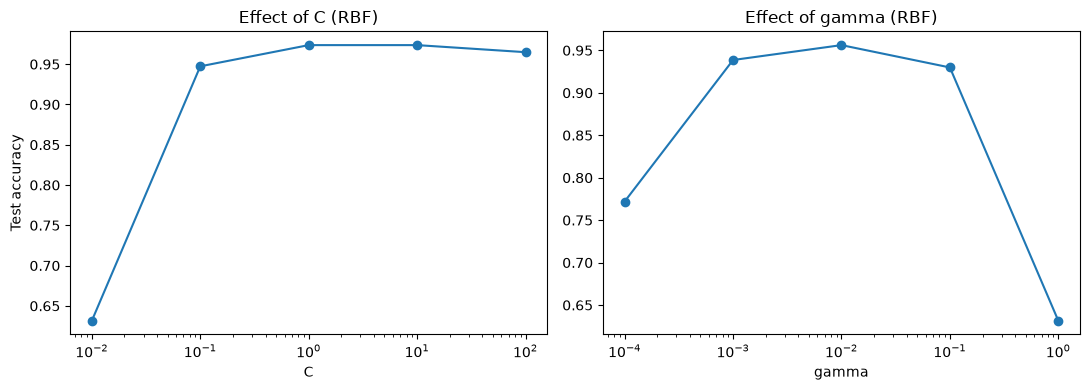

In [10]:
C_values = [0.01, 0.1, 1, 10, 100]
acc_C = [
    accuracy_score(y_test, SVC(kernel="rbf", C=C).fit(X_train_s, y_train).predict(X_test_s))
    for C in C_values
]

gamma_values = [0.0001, 0.001, 0.01, 0.1, 1]
acc_gamma = [
    accuracy_score(y_test, SVC(kernel="rbf", gamma=g).fit(X_train_s, y_train).predict(X_test_s))
    for g in gamma_values
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(C_values, acc_C, marker="o")
axes[0].set_xscale("log"); axes[0].set_xlabel("C"); axes[0].set_ylabel("Test accuracy"); axes[0].set_title("Effect of C (RBF)")
axes[1].plot(gamma_values, acc_gamma, marker="o")
axes[1].set_xscale("log"); axes[1].set_xlabel("gamma"); axes[1].set_title("Effect of gamma (RBF)")
plt.tight_layout()
plt.show()

**Takeaways**:

- Very small `C` underfits; accuracy levels off once `C` is large enough.
- `gamma` has a sweet spot: too small underfits (a nearly linear boundary), and too large overfits (each point only influences its immediate neighbourhood), so accuracy collapses.